# 02 - Modelo baseline

Este notebook construye una primera referencia con regresión logística para tener una línea base interpretable antes de comparar modelos más flexibles.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

## Datos y objetivo

Se carga el dataset y se crea `Target_bin`, manteniendo el mismo criterio de abandono definido en el EDA.

In [2]:
df = pd.read_csv("../data/dataset.csv")
df["Target_bin"] = (df["Target"] == "Dropout").astype(int)

## Selección de variables y partición

Se separan predictores y objetivo, se excluyen columnas no disponibles o directamente ligadas al target, y se crea una partición estratificada de entrenamiento y test.

In [3]:
drop_cols = [
    "Target", "Target_bin",
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)"
]

X = df.drop(columns=drop_cols)
y = df["Target_bin"]

In [4]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["int64", "float64"]).columns.tolist()

print("NumÃƒÂ©ricas:", numeric_features)
print("CategÃƒÂ³ricas:", categorical_features)

NumÃƒÂ©ricas: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP']
CategÃƒÂ³ricas: []


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(3539, 28) (885, 28)
0.3212771969482905 0.32090395480225986


## Preprocesado y pipeline

El pipeline combina imputación, escalado y codificación one-hot. Encapsularlo evita fugas de información entre entrenamiento y evaluación.

In [6]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Entrenamiento del baseline

La regresión logística sirve como referencia inicial: es rápida, estable y facilita interpretar si los modelos posteriores aportan mejora real.

In [7]:
baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

In [8]:
baseline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Marital status',
                                                   'Application mode',
                                                   'Application order',
                                                   'Course',
                                                   'Daytime/evening attendance',
                                                   'Previous qualification',
                                                   'Nacionality',
                                                   "Mother's qualification",
                                                   "Father's qualification",
                                                   "Mother's oc...
                                                   'Curricular units 1st sem '
                                                   '(approved)',
                                                   'Curricular units 1st sem '
                                                   '(grade)',
                                                   'Curricular units 1st sem '
                                                   '(without evaluations)',
                                                   'Unemployment rate',
                                                   'Inflation rate', 'GDP']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [])])),
                ('model', LogisticRegression(max_iter=2000, random_state=42))])

## Evaluación en test

Se calculan métricas globales, matriz de confusión y reporte de clasificación. En este problema son especialmente importantes `recall` y falsos negativos, porque no detectar abandono tiene coste práctico.

In [9]:
y_pred = baseline.predict(X_test)
y_proba = baseline.predict_proba(X_test)[:, 1]

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Accuracy: 0.8564971751412429
Precision: 0.8488888888888889
Recall: 0.6725352112676056
F1: 0.75049115913556
ROC-AUC: 0.9087787959035409


In [11]:
print(classification_report(y_test, y_pred, target_names=["No Dropout", "Dropout"]))

              precision    recall  f1-score   support

  No Dropout       0.86      0.94      0.90       601
     Dropout       0.85      0.67      0.75       284

    accuracy                           0.86       885
   macro avg       0.85      0.81      0.82       885
weighted avg       0.86      0.86      0.85       885



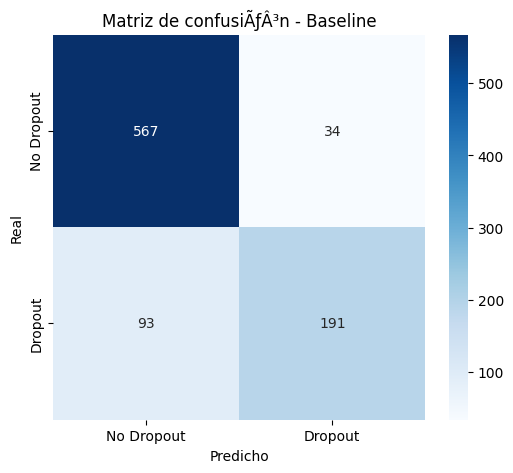

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Dropout", "Dropout"],
            yticklabels=["No Dropout", "Dropout"])
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de confusiÃƒÂ³n - Baseline")
plt.show()

## Validación cruzada

La validación cruzada estima la estabilidad del baseline en entrenamiento y da una referencia más robusta que una única partición.

In [13]:
cv_results = cross_validate(
    baseline,
    X_train, y_train,
    cv=5,
    scoring=["f1", "recall", "precision", "roc_auc"]
)

for metric in cv_results:
    if metric.startswith("test_"):
        print(metric, cv_results[metric].mean(), "Ã‚Â±", cv_results[metric].std())

test_f1 0.7422556835649546 Ã‚Â± 0.024948541921997098
test_recall 0.6736803462400495 Ã‚Â± 0.024472186576068016
test_precision 0.8269178723933228 Ã‚Â± 0.032545424114961446
test_roc_auc 0.8973239289212074 Ã‚Â± 0.012138133363810883
